In [13]:
import joblib, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score

In [14]:
# Load the pipeline
pipeline = joblib.load('../models/trained_pipeline.pkl')

# Load the test data
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# Load the predictions
predictions = pd.read_csv('../data/predictions.csv').squeeze()

## Results

In [15]:
results = pd.DataFrame({
    'Model': ['Government (rfs)', 'Our Model'],
    'R2': ['-', f"{r2_score(y_test, predictions):.4f}"],
    'MAE': [f"{mean_absolute_error(y_test, X_test['rfs']):.4f}", f"{mean_absolute_error(y_test, predictions):.4f}"]
})

results

,Model,R2,MAE
0,Government (rfs),-,7.8753
1,Our Model,0.9879,0.2251


## Monthly MAE

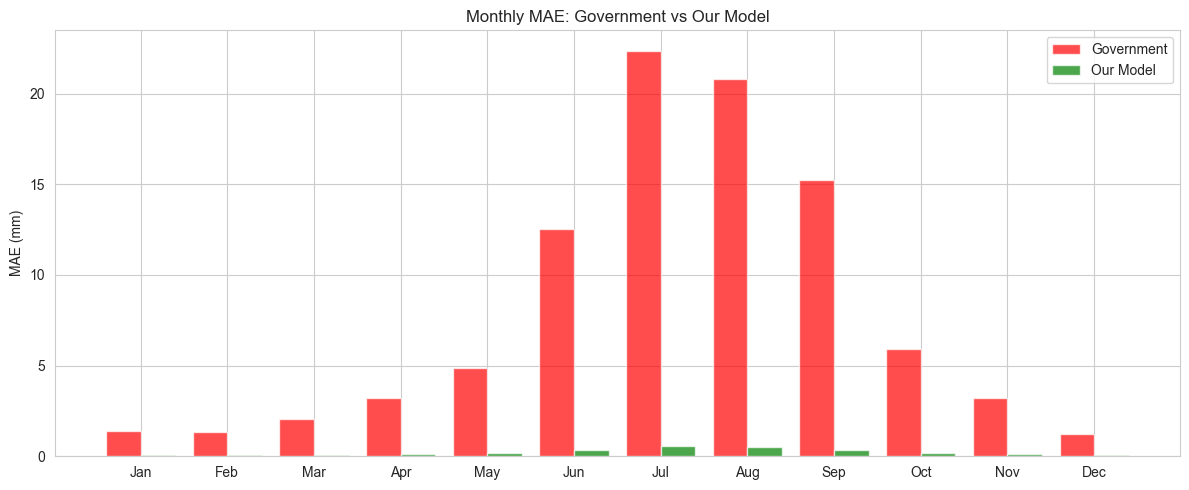

In [16]:
monthly = pd.DataFrame({
    'month': X_test['month'],
    'actual': y_test,
    'predicted': predictions,
    'govt': X_test['rfs']
})

monthly_mae = monthly.groupby('month').apply(lambda x: pd.Series({
    'govt_mae': (x['actual'] - x['govt']).abs().mean(),
    'model_mae': (x['actual'] - x['predicted']).abs().mean()
}), include_groups=False)

# plot
fig, ax = plt.subplots(figsize=(12, 5))
x = range(1, 13)
ax.bar([i - 0.2 for i in x], monthly_mae['govt_mae'], width=0.4, label='Government', color='red', alpha=0.7)
ax.bar([i + 0.2 for i in x], monthly_mae['model_mae'], width=0.4, label='Our Model', color='green', alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('MAE (mm)')
ax.set_title('Monthly MAE: Government vs Our Model')
ax.legend()
plt.tight_layout()

os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/monthly_comparison.png')
plt.show()

## Feature Importance

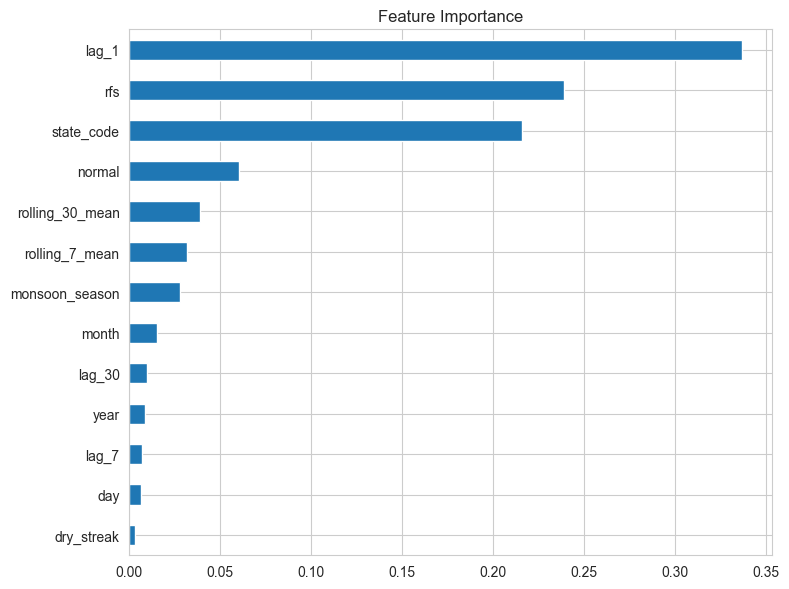

In [17]:
model = pipeline.named_steps['model']
importance = pd.Series(model.feature_importances_, index=X_test.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

## Actual vs Predicted

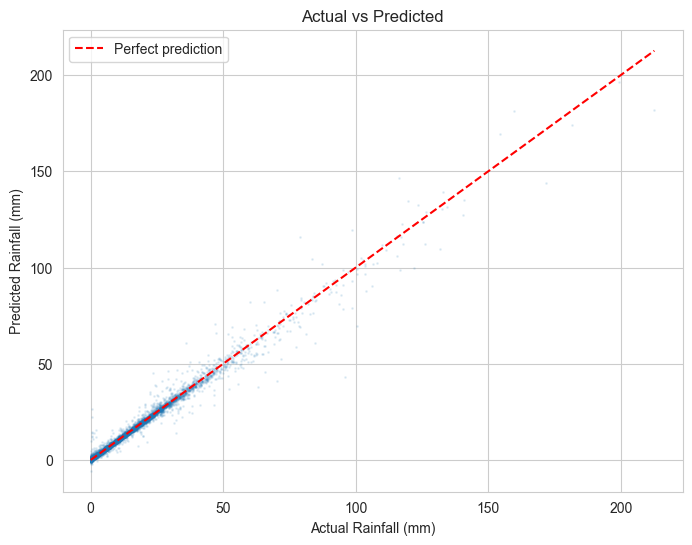

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.1, s=1)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.title('Actual vs Predicted')
plt.legend()
plt.savefig('../reports/actual_vs_predicted.png')
plt.show()

## Journey

In [19]:
journey = pd.DataFrame({
    'Stage': ['Untuned LightGBM', 'Tuned LightGBM', '+ Sample Weights', '+ Stacking'],
    'R2':           [0.9798, 0.9860, 0.9874, 0.9877],
    'MAE':          [0.3484, 0.2636, 0.2443, 0.2486],
    'Monsoon MAE':  [0.8359, 0.5171, 0.4868, 0.4817]
})

print(journey.to_string(index=False))

           Stage     R2    MAE  Monsoon MAE
Untuned LightGBM 0.9798 0.3484       0.8359
  Tuned LightGBM 0.9860 0.2636       0.5171
+ Sample Weights 0.9874 0.2443       0.4868
      + Stacking 0.9877 0.2486       0.4817
